<a href="https://colab.research.google.com/github/jsansao/teic_tp_mock/blob/main/tp2_penguins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático 2 (TP2) - Ciência de Dados
## Dataset: Palmer Penguins (Análise Exploratória e Visualização Biológica)

Este notebook apresenta a resolução da segunda etapa (TP2) para o dataset *Palmer Penguins*. O foco desta etapa é a **Análise Exploratória de Dados (EDA)**, tratamento justificado de nulos por espécie, visualização de dispersão morfológica, codificação de categóricas e padronização.

---

## 1. Revisão da Formalização do Problema e Objetivos

### 1.1 Resumo do Problema
O objetivo é classificar a espécie de pinguim ($Y \in \{\text{'Adelie'}, \text{'Chinstrap'}, \text{'Gentoo'}\}$) com base em 4 medições morfológicas e 2 atributos ambientais/demográficos.

### 1.2 Objetivos Pretendidos
*   Inspecionar e tratar os dados ausentes de forma estatisticamente conservadora.
*   Explorar visualmente as relações bivariadas entre as medições morfológicas (ex: comprimento da nadadeira vs. bico).
*   Codificar as variáveis categóricas (`island`, `sex`) e aplicar padronização Z-score (`StandardScaler`).
*   Definir as decisões de projeto e o planejamento metodológico para o TP3.

---

## 2. Análise Exploratória dos Dados (EDA) e Transformações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"
df = pd.read_csv(url)

print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head()

Dimensões do dataset: 344 linhas e 8 colunas.


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### 2.1 Inspeção e Tratamento de Dados Ausentes
Vamos checar os nulos presentes na base.

In [2]:
print("Dados faltantes por coluna:")
print(df.isnull().sum())

Dados faltantes por coluna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


#### Decisão sobre os Dados Ausentes:
Como o total de registros com valores ausentes é muito pequeno (~11 linhas de 344, representando menos de 3% da base), preencheremos as medições numéricas ausentes com a **mediana de cada espécie** e o sexo ausente com a **moda de cada espécie**, preservando o tamanho total do dataset sem introduzir ruído cruzado entre espécies.

In [3]:
# Imputação de variáveis numéricas pela mediana da espécie
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
for col in num_cols:
    df[col] = df.groupby('species')[col].transform(lambda x: x.fillna(x.median()))

# Imputação de 'sex' pela moda dentro da espécie
df['sex'] = df.groupby('species')['sex'].transform(lambda x: x.fillna(x.mode()[0]))

print("Confirmando ausência de nulos após imputação:")
print(df.isnull().sum().sum())

Confirmando ausência de nulos após imputação:
0


### 2.2 Visualizações e Informações Estatísticas

#### 1. Frequência de Espécies por Ilha

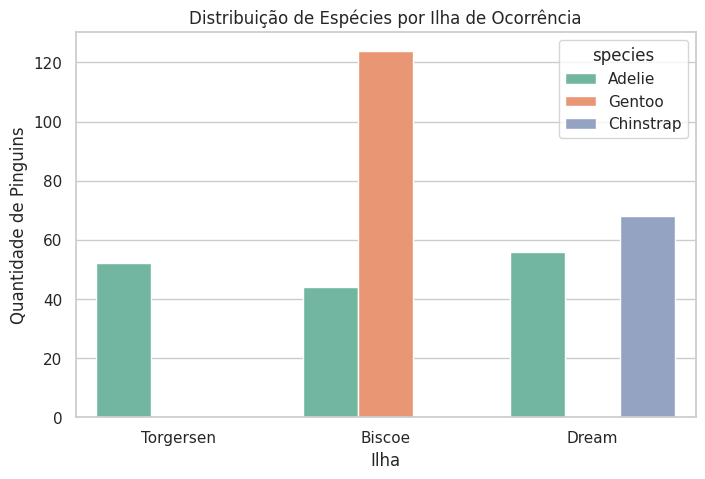

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='island', hue='species', palette='Set2')
plt.title('Distribuição de Espécies por Ilha de Ocorrência')
plt.xlabel('Ilha')
plt.ylabel('Quantidade de Pinguins')
plt.show()

#### 2. Relação Morfológica: Comprimento da Nadadeira vs Comprimento do Bico (Gráfico Emblemático)

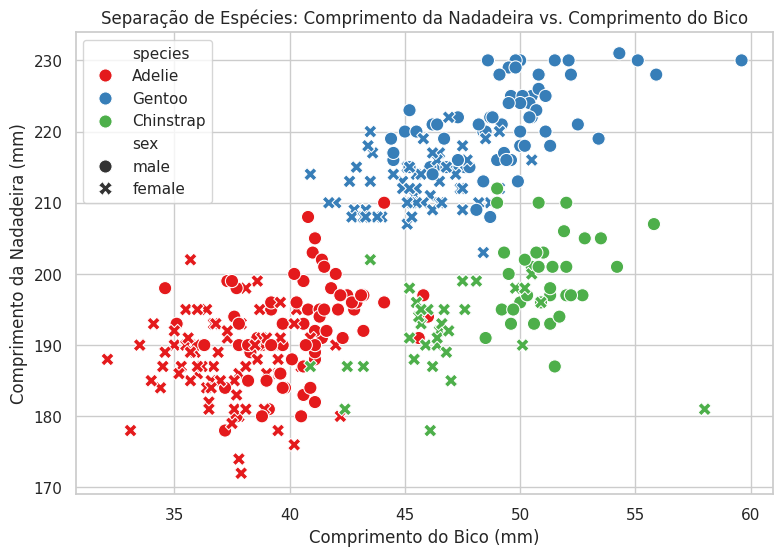

In [5]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='bill_length_mm',
    y='flipper_length_mm',
    hue='species',
    style='sex',
    s=90,
    palette='Set1'
)
plt.title('Separação de Espécies: Comprimento da Nadadeira vs. Comprimento do Bico')
plt.xlabel('Comprimento do Bico (mm)')
plt.ylabel('Comprimento da Nadadeira (mm)')
plt.show()

#### 3. Distribuição da Massa Corporal por Espécie

/tmp/ipykernel_594/1375411924.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='body_mass_g', palette='Pastel1')


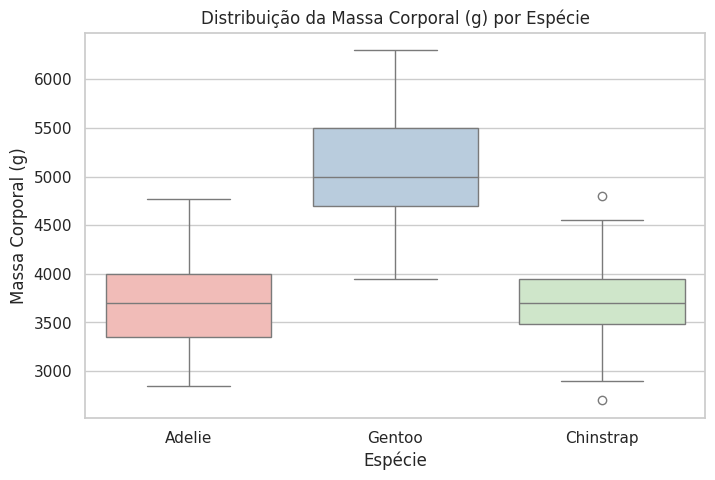

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='species', y='body_mass_g', palette='Pastel1')
plt.title('Distribuição da Massa Corporal (g) por Espécie')
plt.xlabel('Espécie')
plt.ylabel('Massa Corporal (g)')
plt.show()

#### 4. Matriz de Correlação das Variáveis Morfológicas

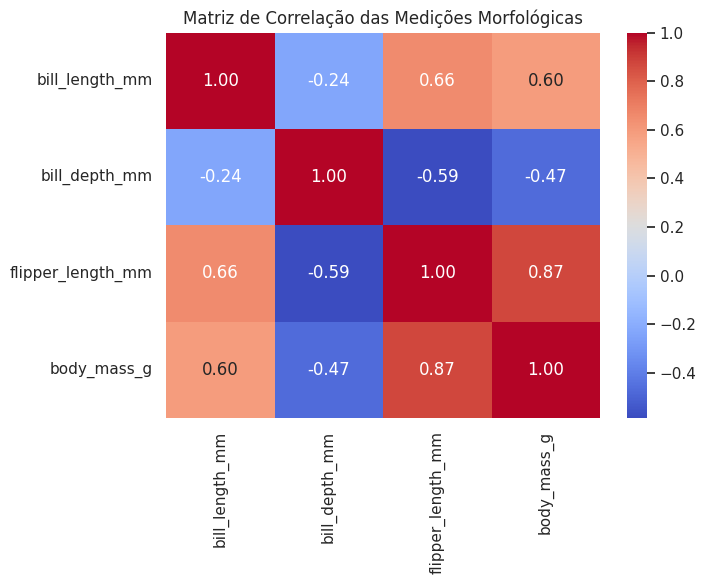

In [7]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Medições Morfológicas')
plt.show()

### 2.3 Codificação Categórica e Padronização Numérica

1.  **One-Hot Encoding:** Aplicado nas colunas `island` e `sex`.
2.  **StandardScaler:** Padronização Z-score nas 4 medições numéricas para igualar as escalas.

In [8]:
from sklearn.preprocessing import StandardScaler

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=['island', 'sex'], drop_first=True)

# Converter booleanos para inteiro
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

# Remover coluna 'year' (não relevante taxonomicamente)
if 'year' in df_encoded.columns:
    df_encoded = df_encoded.drop(columns=['year'])

# Padronização numérica
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

df_encoded.head()

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_male
0,Adelie,-0.884513,0.787248,-1.419709,-0.565724,0,1,1
1,Adelie,-0.811061,0.127594,-1.063487,-0.503229,0,1,0
2,Adelie,-0.664158,0.432050,-0.422288,-1.190672,0,1,0
3,Adelie,-0.939601,0.635020,-0.778510,-0.628218,0,1,0
4,Adelie,-1.325221,1.091704,-0.564777,-0.940693,0,1,0


---

## 3. Principais Decisões de Projeto

### 3.1 Descrição das Decisões
1.  **Imputação por Mediana/Moda Dentro da Espécie:** Preserva as 11 amostras com nulos sem distorcer as diferenças morfológicas entre as 3 espécies.
2.  **Descarte da Variável `year`:** O ano da coleta representa apenas o momento da expedição e não possui significado biológico para a classificação da espécie.
3.  **Padronização Z-Score:** Garante que a massa corporal (na casa de milhares de gramas) não domine variáveis medidas em milímetros durante o treinamento de modelos lineares e Redes Neurais no TP3.

### 3.2 Revisão da Literatura
*   **Gorman et al. (2014)** explicam que pinguins *Gentoo* são significativamente maiores em massa corporal e comprimento de nadadeira, enquanto *Chinstrap* e *Adelie* se diferenciam fortemente pela profundidade e comprimento do bico. O gráfico de dispersão confirma perfeitamente essa observação ecológica.

---

## 4. Metodologia de Modelagem (TP3)

No TP3, treinaremos os seguintes algoritmos:
1.  **Regressão Logística Multinomial:** Baseline linear interpretável.
2.  **Random Forest Classifier:** Modelo ensemble para capturar limiares de decisão morfológicos.
3.  **Rede Neural MLPClassifier:** Modelo de aprendizagem profunda básico.

Métricas: Acurácia, F1-Score Macro e Matriz de Confusão Multiclasse.
